In [1]:
from astropy import constants as const
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

def grid_R(NR, dR):
    R = np.zeros(NR)
    l = 10 / dR
    for i in range(NR):
        if i * dR < 10:
            R[i] = i * dR
        else:
            R[i] = 10** ((i + l ) / 2 / l)
    return R
def grid_Z(NZ, dZ):
    Z = np.zeros(NZ)
    l = 1 / dZ
    for i in range(NZ):
        if i * dZ < 1:
            Z[i] = i * dZ
        else:
            Z[i] = 10** ((i - l) / l)
    return Z
NR = 300
NZ = 150
Rf = grid_R(NR + 1,0.1)
Zf = grid_Z(NZ + 1,0.02)
Rc = (Rf[1:] + Rf[:-1]) / 2
Zc = (Zf[1:] + Zf[:-1]) / 2

In [2]:

ndis_C = np.fromfile("ndis_C_const_inj_dt100_vR.bin",dtype = np.float64).reshape(1000,NR + 4, NZ + 4)
ndis_C_in = ndis_C[:,2:-2,2:-2]
ndis_C_log = np.log10(ndis_C_in + 1e-100)

fig, ax = plt.subplots()

ndis = ax.pcolormesh(Rc, Zc, ndis_C_in[0].T,shading="auto", vmin = 0, vmax = 100 )

cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('linear scale') 

def animate(i):
    ndis.set_array(ndis_C_in[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=1000,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

(1.0, 1000.0)

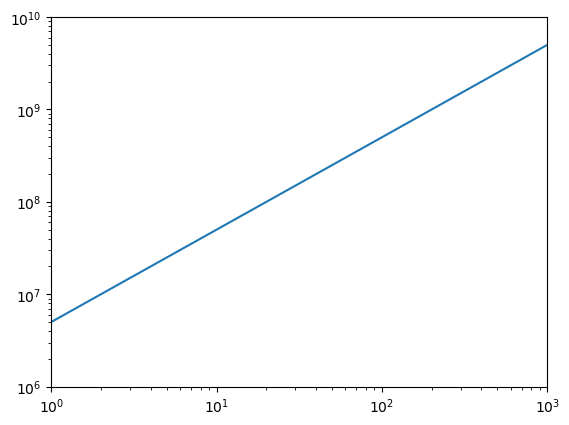

In [6]:
dV = Rc[:, None] * np.diff(Rf)[:,None] * np.diff(Zf)[None,:]
N_tot = np.sum(ndis_C_in * dV[None,:], axis = (1,2))
t = np.arange(1000)
plt.plot(t, N_tot)
plt.xscale("log")
plt.yscale("log")
plt.ylim(1e6,1e10)
plt.xlim(1e0,1e3)

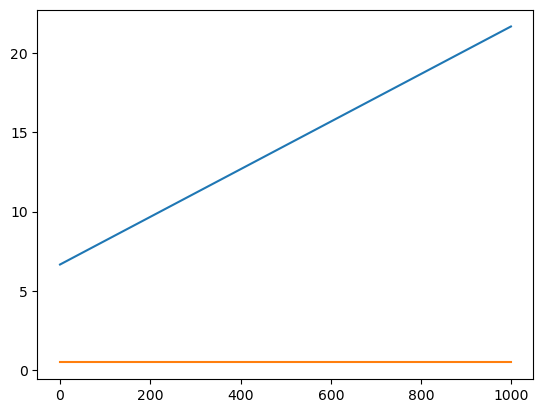

In [7]:
mc_R = np.sum(ndis_C_in * Rc[None, :, None] * dV[None,:], axis = (1,2)) / N_tot
mc_Z = np.sum(ndis_C_in * Zc[None, None, :] * dV[None,:], axis = (1,2)) / N_tot

plt.plot(t, mc_R)
plt.plot(t, mc_Z)

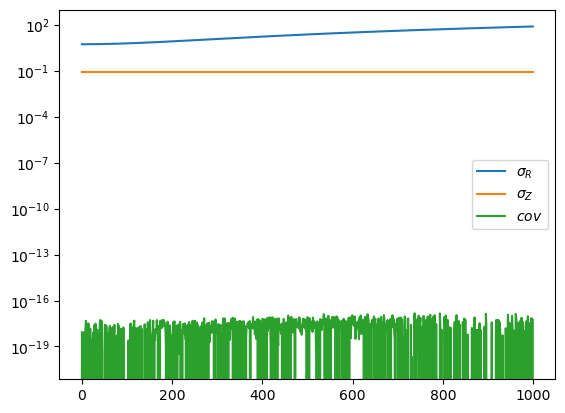

In [13]:
sigma_R = np.sum((Rc[None,:,None] - mc_R[:,None,None])**2 * ndis_C_in * dV[None,:], axis = (1,2)) / N_tot 
sigma_Z = np.sum((Zc[None,None,:] - mc_Z[:,None,None])**2 * ndis_C_in * dV[None,:], axis = (1,2)) / N_tot 
cov = np.sum((Rc[None,:,None]-mc_R[:,None,None])*(Zc[None,None,:]-mc_Z[:,None,None])*ndis_C_in*dV[None,:,:],axis=(1,2))/N_tot
plt.plot(t, sigma_R, label = f"$\sigma_R$")
plt.plot(t, sigma_Z, label = f"$\sigma_Z$")
plt.plot(t, cov, label = f"$cov$")
plt.legend()
plt.yscale("log")

In [10]:
sigma_Z

array([0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833,
       0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833,
       0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833,
       0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833,
       0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833,
       0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833,
       0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833,
       0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833,
       0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833,
       0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833,
       0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833,
       0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833,
       0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833,
       0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833, 0.0833,
      